# Next Token Prediction — Bigram Language Model

Reproduces the simplest possible language model from Karpathy's *Let's build GPT* series.
It contains only a forward pass, cross-entropy loss, and a token generator — no attention.
The embedding table rows are the unnormalized next-token logits (one row per current token).

## Setup

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(1337)

## Training Data

Synthetic data where every character is `'a'`, followed by a next character drawn from
a fixed distribution:
- `'b'` with prob 0.50
- `'c'` with prob 0.20
- `'d'` with prob 0.10
- `e–z` with prob 0.20 (uniform)

The model should be able to recover this distribution after training.

In [2]:
def generate_training_data_uniform(size: int) -> str:
    data_int = np.random.randint(ord('a'), ord('z') + 1, size=size).tolist()
    return "".join(chr(x) for x in data_int)


def generate_training_data_special_pattern(size: int) -> str:
    """Every pair is 'a' followed by b/c/d/e-z with fixed probabilities."""
    data_int = []
    i = 0
    while i < size - 1:
        data_int.append(ord('a'))
        i += 1
        r = np.random.rand()
        if r <= 0.50:
            data_int.append(ord('b'))
        elif r <= 0.70:
            data_int.append(ord('c'))
        elif r <= 0.80:
            data_int.append(ord('d'))
        else:
            data_int.append(int(np.random.randint(ord('e'), ord('z') + 1)))
        i += 1
    if i < size:
        data_int.append(int(np.random.randint(ord('b'), ord('z') + 1)))
    return "".join(chr(x) for x in data_int)


training_data = generate_training_data_special_pattern(100_000)
print(training_data[:100])
print(f"a:  {training_data.count('a')}")
print(f"ab: {training_data.count('ab')}  (target ~50%)")
print(f"ac: {training_data.count('ac')}  (target ~20%)")
print(f"ad: {training_data.count('ad')}  (target ~10%)")
print(f"ae: {training_data.count('ae')}  (target small)")

ababacajabababadababaiabadabamahacababajadaracabacabadabaeababababababajabababajababalababacabacasab
a:  50000
ab: 24964  (target ~50%)
ac: 9960  (target ~20%)
ad: 5071  (target ~10%)
ae: 438  (target small)


## Vocabulary

All unique characters present in the training string, sorted alphabetically.
Provides `encode` (str → int list) and `decode` (int list → str).

In [3]:
class Vocabulary:
    def __init__(self, data: str):
        self.vocabulary = sorted(set(data))
        self.stoi = {c: i for i, c in enumerate(self.vocabulary)}
        self.itos = {i: c for i, c in enumerate(self.vocabulary)}

    def encode_data(self, text: str) -> list:
        return [self.stoi[x] for x in text]

    def decode_data(self, tokens: list) -> str:
        return "".join(self.itos[x] for x in tokens)

    def size(self) -> int:
        return len(self.vocabulary)


vocabulary = Vocabulary(training_data)
print(f"Vocabulary size: {vocabulary.size()}")
print(f"Characters: {''.join(vocabulary.vocabulary)}")

Vocabulary size: 26
Characters: abcdefghijklmnopqrstuvwxyz


## Dataset

Encode the string as a 1-D integer tensor, then split 90/10 into train and validation.

In [4]:
data = torch.tensor(vocabulary.encode_data(training_data), dtype=torch.long)
print(data[:10])

n = int(0.9 * len(data))
train_data = data[:n]
val_data   = data[n:]

tensor([0, 1, 0, 1, 0, 2, 0, 9, 0, 1])


## Batching

`get_batch` samples random windows of length `block_size` from the corpus.
Each position in the window is an (input, target) pair, so one window yields
`block_size` training examples.

In [5]:
BATCH_SIZE = 32
BLOCK_SIZE = 8


def get_batch(split: str):
    src = train_data if split == 'train' else val_data
    ix = torch.randint(len(src) - BLOCK_SIZE, (BATCH_SIZE,))
    x = torch.stack([src[i:i + BLOCK_SIZE]     for i in ix])
    y = torch.stack([src[i + 1:i + BLOCK_SIZE + 1] for i in ix])
    return x, y


xb, yb = get_batch('train')
print(xb)
print(yb)

tensor([[ 1,  0,  1,  0,  2,  0,  2,  0],
        [ 1,  0,  1,  0,  1,  0,  2,  0],
        [ 0,  2,  0,  2,  0,  1,  0,  3],
        [ 0,  1,  0,  2,  0, 18,  0,  1],
        [ 1,  0, 19,  0,  1,  0,  1,  0],
        [ 3,  0, 23,  0, 18,  0,  1,  0],
        [25,  0,  1,  0,  1,  0,  2,  0],
        [ 0, 20,  0,  2,  0,  1,  0,  1],
        [ 0, 24,  0,  1,  0,  2,  0,  1],
        [ 0,  2,  0,  3,  0,  1,  0, 15],
        [ 0,  3,  0,  2,  0,  1,  0,  3],
        [ 0,  3,  0,  1,  0,  1,  0,  3],
        [ 3,  0,  2,  0,  2,  0,  1,  0],
        [ 0,  2,  0,  1,  0,  1,  0,  2],
        [ 0,  1,  0,  1,  0,  1,  0, 16],
        [ 0,  1,  0,  6,  0,  1,  0,  1],
        [ 1,  0,  1,  0,  3,  0,  2,  0],
        [ 0,  2,  0,  2,  0,  3,  0,  7],
        [ 1,  0,  1,  0,  1,  0,  3,  0],
        [ 2,  0,  1,  0,  1,  0,  2,  0],
        [ 1,  0,  4,  0,  1,  0,  1,  0],
        [ 0,  2,  0, 10,  0,  3,  0,  1],
        [ 0,  1,  0,  1,  0,  2,  0,  2],
        [ 0, 22,  0,  1,  0,  3,  

## Model

The simplest language model: a single `nn.Embedding` table of shape
`(vocab_size, vocab_size)`.  
Row `i` holds the unnormalized log-probabilities for every token that could
follow token `i` — no context from earlier positions is used.

This is the *bigram* model: prediction depends only on the current token.

In [6]:
class BigramLanguageModel(nn.Module):

    def __init__(self, vocab: Vocabulary):
        super().__init__()
        vocab_size = vocab.size()
        # Rows = current token index; values = logits over next token
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        # idx: (B, T)  →  logits: (B, T, vocab_size)
        logits = self.token_embedding_table(idx)

        if targets is None:
            return logits, None

        B, T, C = logits.shape
        loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens: int):
        # idx: (B, T) — running context; we extend it one token at a time
        for _ in range(max_new_tokens):
            logits, _ = self(idx)
            probs = F.softmax(logits[:, -1, :], dim=-1)  # (B, vocab_size)
            idx_next = torch.multinomial(probs, num_samples=1)  # (B, 1)
            idx = torch.cat([idx, idx_next], dim=1)
        return idx


torch.manual_seed(1337)
network = BigramLanguageModel(vocabulary)

logits, loss = network(xb, yb)
print(f"logits shape: {logits.shape}")
print(f"initial loss: {loss.item():.4f}")

sample = network.generate(torch.zeros((1, 1), dtype=torch.long), max_new_tokens=100)[0].tolist()
print(vocabulary.decode_data(sample))

logits shape: torch.Size([32, 8, 26])
initial loss: 4.3381
asgxsgoqyyfumiievbyjzqfvjzsojhzwqyfaqbfdanvqwlnruqyfapzmifvfpqfojgfigdfdeznvfbfaqfsihhdkceejzwciyfpjg


## Training

In [7]:
optimizer = torch.optim.AdamW(network.parameters(), lr=1e-3)

for step in range(10_000):
    xb, yb = get_batch('train')
    logits, loss = network(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(f"final train loss: {loss.item():.4f}")

final train loss: 0.9758


## Evaluation

Generate a long sequence and compare bigram frequencies to the target distribution.

In [8]:
start = torch.zeros((1, 1), dtype=torch.long)
generated = network.generate(start, max_new_tokens=2000)[0].tolist()
output = vocabulary.decode_data(generated)

print(output[:100])
n_a = output.count('a')
print(f"ab: {output.count('ab') / n_a:.1%}  (target 50%)")
print(f"ac: {output.count('ac') / n_a:.1%}  (target 20%)")
print(f"ad: {output.count('ad') / n_a:.1%}  (target 10%)")
print(f"ae: {output.count('ae') / n_a:.1%}  (target ~1%)")

acacarabahabababacabapabadacacabaracasabaqacadacadabacabadababababacabacabababacacabacaxadagakaxabab
ab: 50.9%  (target 50%)
ac: 20.1%  (target 20%)
ad: 9.1%  (target 10%)
ae: 1.0%  (target ~1%)


## Inspect Learned Weights

Row 0 of the embedding table corresponds to token `'a'`.
After softmax it should approximate the true next-token distribution.

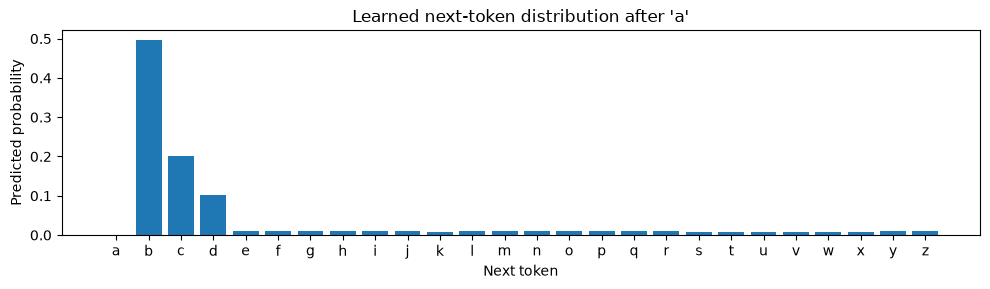

In [9]:
w0 = network.token_embedding_table.weight.data[0]
probs = F.softmax(w0, dim=-1).cpu().numpy()

plt.figure(figsize=(10, 3))
plt.bar(range(len(probs)), probs)
plt.xticks(range(vocabulary.size()), vocabulary.vocabulary)
plt.xlabel("Next token")
plt.ylabel("Predicted probability")
plt.title("Learned next-token distribution after 'a'")
plt.tight_layout()
plt.show()